### Exercise 1

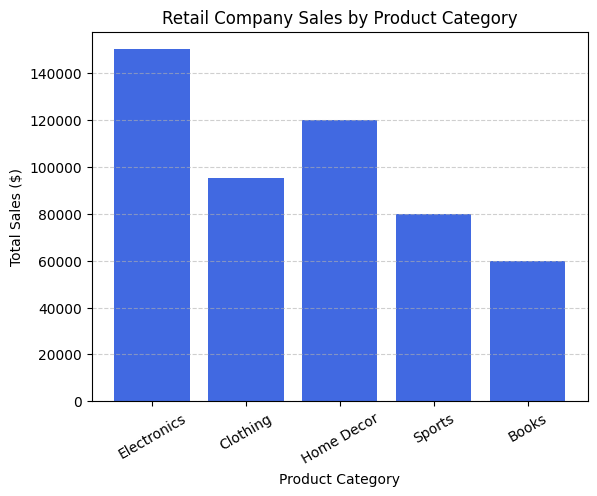

In [1]:
import matplotlib.pyplot as plt
import pandas as pd


data = {
    'Category': ['Electronics', 'Clothing', 'Home Decor', 'Sports', 'Books'],
    'Sales': [150000, 95000, 120000, 80000, 60000]
}
df_sales = pd.DataFrame(data)

# Bar graph
plt.bar(df_sales['Category'], df_sales['Sales'], color='royalblue')

# Customizing the graph
plt.title("Retail Company Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


### Exercise 2: Hierarchical Indexing

In [2]:
import numpy as np
import pandas as pd

# Hierarchical index data
data = {
    'Temperature (°C)': [25, 31, 28, 32, 33, 22, 30, 35]
}
index = pd.MultiIndex.from_tuples([
    ('Canada', 'Toronto', '2025-07-01'),
    ('Canada', 'Toronto', '2025-07-02'),
    ('Canada', 'Vancouver', '2025-07-01'),
    ('Canada', 'Vancouver', '2025-07-02'),
    ('Canada', 'Montreal', '2025-07-01'),
    ('Canada', 'Montreal', '2025-07-02'),
    ('USA', 'New York', '2025-07-01'),
    ('USA', 'New York', '2025-07-02'),
], names=['Country', 'City', 'Date'])

df_temp = pd.DataFrame(data, index=index)
df_temp


Temperature (°C)
Country City      Date                        
Canada  Toronto   2025-07-01                25
                  2025-07-02                31
        Vancouver 2025-07-01                28
                  2025-07-02                32
        Montreal  2025-07-01                33
                  2025-07-02                22
USA     New York  2025-07-01                30
                  2025-07-02                35

In [3]:
# Filter: Only Canada and temperature > 30°C
filtered = df_temp.loc['Canada']
filtered = filtered[filtered['Temperature (°C)'] > 30]

filtered


,,Temperature (°C)
City,Date,
Toronto,2025-07-02,31
Vancouver,2025-07-02,32
Montreal,2025-07-01,33


### Explanation:
### Hierarchical indexing allows us to organize data on multiple levels (Country → City → Date).
### This makes it easier to filter, slice, and analyze specific parts of complex datasets.
### Instead of flat columns, you can directly access subsets like df_temp.loc['Canada'].


### Exercise 3: Advanced Filtering with Hierarchical Indices

In [4]:
arrays = [
    ['IT', 'IT', 'HR', 'HR', 'Finance', 'Finance'],
    ['Alice', 'Bob', 'Carla', 'David', 'Eve', 'Frank']
]
index = pd.MultiIndex.from_arrays(arrays, names=('Department', 'Employee'))

df_salary = pd.DataFrame({
    'Salary': [60000, 45000, 52000, 48000, 75000, 65000]
}, index=index)

df_salary


Salary
Department Employee        
IT         Alice      60000
           Bob        45000
HR         Carla      52000
           David      48000
Finance    Eve        75000
           Frank      65000

In [5]:
# Filter for salaries > 50,000
filtered_salary = df_salary[df_salary['Salary'] > 50000]
filtered_salary


Salary
Department Employee        
IT         Alice      60000
HR         Carla      52000
Finance    Eve        75000
           Frank      65000

### Hierarchical indexing helps group related records
### and perform filtering without needing to flatten or merge multiple columns.


### Exercise 4: Visualizing Movie Durations

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df_movies = pd.DataFrame({
    'Movie': ['Iron Man', 'Avengers', 'Doctor Strange', 'Black Panther', 'Endgame'],
    'Duration': [126, 143, 115, 134, 181]
})
df_movies


,Movie,Duration
0,Iron Man,126
1,Avengers,143
2,Doctor Strange,115
3,Black Panther,134
4,Endgame,181


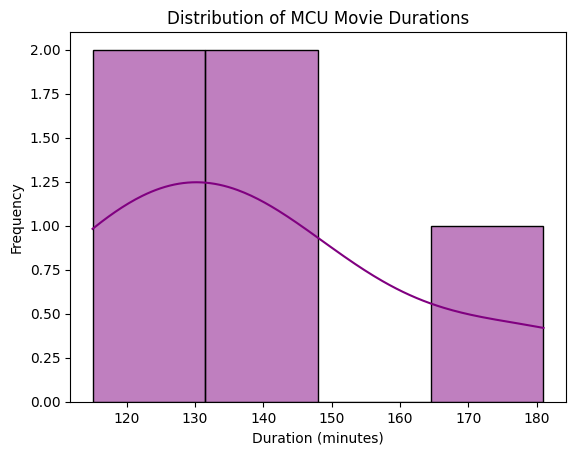

In [7]:
sns.histplot(df_movies['Duration'], kde=True, color='purple')

plt.title("Distribution of MCU Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()


### Exercise 5: Box Plot of Audience and Tomato Meter Scores

In [8]:
df_scores = pd.DataFrame({
    'Movie': ['Iron Man', 'Avengers', 'Black Panther', 'Endgame'],
    'TomatoMeter': [94, 91, 96, 94],
    'AudienceScore': [91, 92, 97, 90]
})

df_melted = df_scores.melt(id_vars='Movie', value_vars=['TomatoMeter', 'AudienceScore'],
                           var_name='ScoreType', value_name='Score')
df_melted


,Movie,ScoreType,Score
0,Iron Man,TomatoMeter,94
1,Avengers,TomatoMeter,91
2,Black Panther,TomatoMeter,96
3,Endgame,TomatoMeter,94
4,Iron Man,AudienceScore,91
5,Avengers,AudienceScore,92
6,Black Panther,AudienceScore,97
7,Endgame,AudienceScore,90


C:\Users\PC\AppData\Local\Temp\ipykernel_14812\3905380891.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='ScoreType', y='Score', palette='Set3')


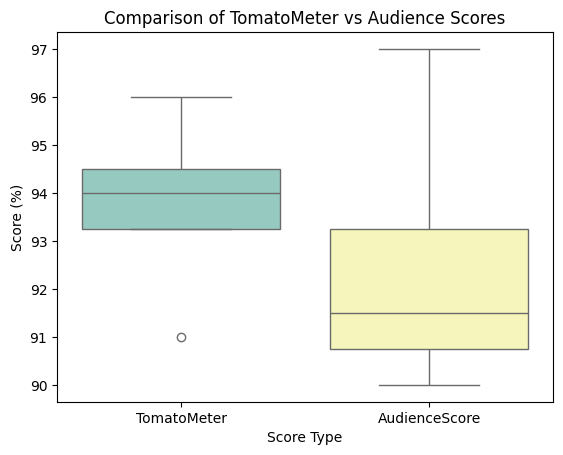

In [9]:
sns.boxplot(data=df_melted, x='ScoreType', y='Score', palette='Set3')

plt.title("Comparison of TomatoMeter vs Audience Scores")
plt.xlabel("Score Type")
plt.ylabel("Score (%)")
plt.show()


### Exercise 6: Pair Plot of Financial Data

In [10]:
df_finance = pd.DataFrame({
    'Production Budget': [140e6, 220e6, 165e6, 356e6, 200e6],
    'Opening Weekend': [98e6, 207e6, 85e6, 357e6, 169e6],
    'Domestic Box Office': [318e6, 623e6, 232e6, 858e6, 678e6],
    'Worldwide Box Office': [585e6, 1518e6, 677e6, 2798e6, 2187e6],
    'MCU_Phase': ['Phase 1', 'Phase 1', 'Phase 3', 'Phase 3', 'Phase 3']
})
df_finance


,Production Budget,Opening Weekend,Domestic Box Office,Worldwide Box Office,MCU_Phase
0,140000000.0,98000000.0,318000000.0,5.850000e+08,Phase 1
1,220000000.0,207000000.0,623000000.0,1.518000e+09,Phase 1
2,165000000.0,85000000.0,232000000.0,6.770000e+08,Phase 3
3,356000000.0,357000000.0,858000000.0,2.798000e+09,Phase 3
4,200000000.0,169000000.0,678000000.0,2.187000e+09,Phase 3


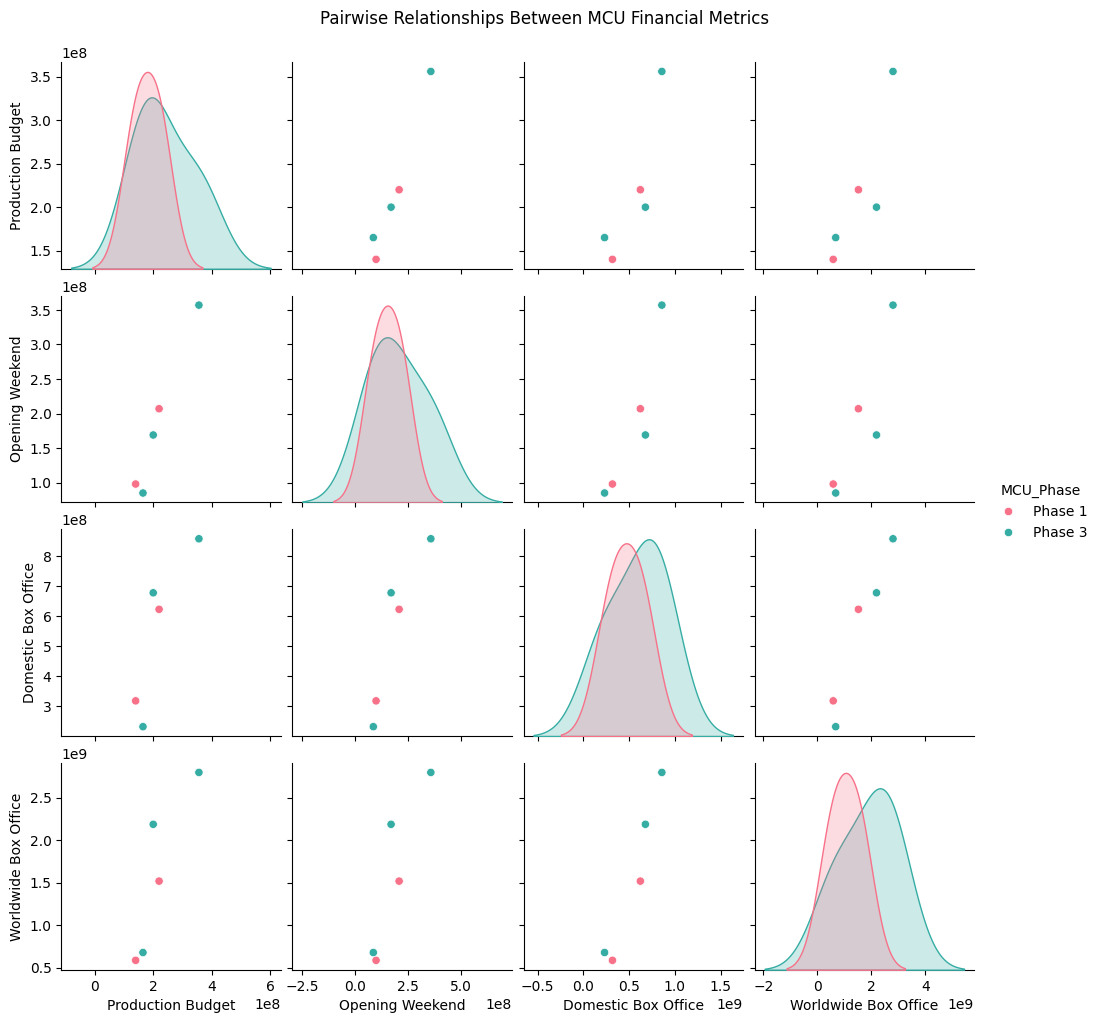

In [11]:
sns.pairplot(df_finance, 
             vars=['Production Budget', 'Opening Weekend', 'Domestic Box Office', 'Worldwide Box Office'],
             hue='MCU_Phase', 
             palette='husl')

plt.suptitle("Pairwise Relationships Between MCU Financial Metrics", y=1.02)
plt.show()
